# Bài 5: Trích xuất đặc trưng MFCC (không dùng librosa)

**Mục tiêu:**
- Tính MFCC để dùng cho các bài toán ML (nhận diện, phân loại).
- Tránh phụ thuộc `librosa` (phòng trường hợp lỗi), dùng `python_speech_features`.

**Thư viện:** `python_speech_features`, `scipy`.

In [ ]:
#@title Cài đặt (nếu cần)
# !pip install python_speech_features scipy matplotlib


MFCC shape: (638, 13)


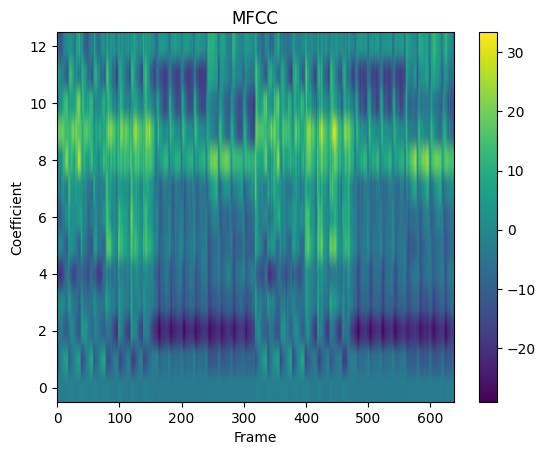

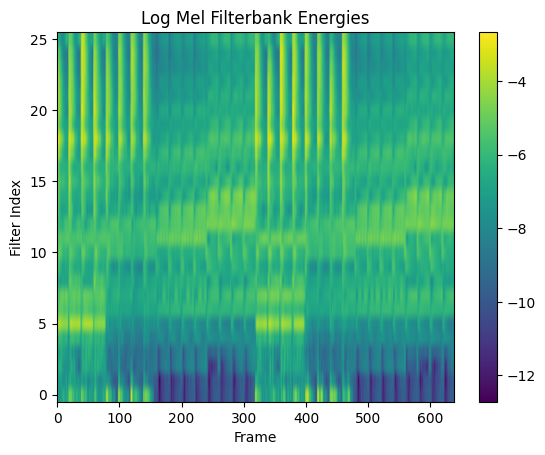

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from python_speech_features import mfcc, logfbank

filename = "sample-6s.wav"  # Thay bằng của bạn
rate, data = wavfile.read(filename)
if data.ndim == 2:
    data = data[:,0]

# Nếu dữ liệu là int16 -> chuyển float
if data.dtype.kind in ('i', 'u'):
    data = data.astype(np.float32) / 32768.0

# Tính MFCC
mfcc_feat = mfcc(signal=data, samplerate=rate, numcep=13, nfft=2048)
print("MFCC shape:", mfcc_feat.shape)

# Hiển thị như ảnh
plt.figure()
plt.imshow(mfcc_feat.T, aspect='auto', origin='lower')
plt.title("MFCC")
plt.xlabel("Frame")
plt.ylabel("Coefficient")
plt.colorbar()
plt.show()

# Log Mel filterbank energies
fbank_feat = logfbank(signal=data, samplerate=rate, nfft=2048)
plt.figure()
plt.imshow(fbank_feat.T, aspect='auto', origin='lower')
plt.title("Log Mel Filterbank Energies")
plt.xlabel("Frame")
plt.ylabel("Filter Index")
plt.colorbar()
plt.show()